In [43]:
!pip install -q -r requirements.txt

In [44]:
import warnings
warnings.filterwarnings("ignore")

In [45]:
import os
import time

import numpy as np
import cv2
import onnxruntime as ort

from postprocess_db import DBPostProcess
import matplotlib.pyplot as plt

# Создание onnx сессии

In [46]:
def create_onnx_sessions(
    det_model_path, rec_model_path, providers=["CPUExecutionProvider"]
):
    """Создание сессии ONNX runtime"""

    sess_options = ort.SessionOptions()

    # настройки оптимизации в ORT сессии
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    # Параллелизм для CPU
    sess_options.intra_op_num_threads = os.cpu_count() // 2  # потоки для операций (4)
    sess_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL

    # Создание ORT сессий (для детекции и распознавания)
    det_session = ort.InferenceSession(
        det_model_path, providers=providers, sess_options=sess_options
    )
    rec_session = ort.InferenceSession(
        rec_model_path, providers=providers, sess_options=sess_options
    )

    # Вывод фиксированных параметров входа и выхода rec модели (для отладки)
    print(
        f"rec_input_info [batch_size, colors, H, W] = {rec_session.get_inputs()[0].shape}"
    )
    print(
        f"rec_output_shape [batch_size, seq_len, classes] ={rec_session.get_outputs()[0].shape}"
    )

    return det_session, rec_session

In [47]:
def load_charset(dict_path, n_classes):
    """Создание списка из словаря для расшифровки предсказания rec модели"""

    charset = [""]  # blank symbol, id=0

    with open(dict_path, "r", encoding="utf-8") as f:
        for line in f:
            charset += line.rstrip("\n")

    if len(charset) < n_classes:
        charset += [" "] * (n_classes - len(charset))

    # print(f'charset = {charset}')

    return charset

#  Составные части OCR алгоритма

Детекция:
  - Препроцессинг изображения: масштабирование в размер // 32, нормализация RGB каналов, перестановка осей в формат []
  - Инференс -> карта веротности 'текст / не текст'
  - Постобработка карты вероятностей: бинаризация, поиск контуров, расчёт вероятности внутри контуров и фильтрация, обратное масштабирование в исходный размер

Распознавание:
- Вырезание текстовой области из исходного изображения с коррекцией перспективы
- Инференс -> матрица вероятностей (seq_len, n_classes) для каждого индекса текстовой строки по символам из charset
- Декодирование с помощью argmax

## Препроцессинг для модели детекции

In [48]:
def resize_image_det(img, target_size=960):
    """Масштаб исходного изображения для det модели (960, 960).
    Размер изображения и паддинг кратный 32 - важно для архитектуры det модели"""

    h, w = img.shape[:2]

    resized_w = w
    resized_h = h

    if max(resized_w, resized_h) > target_size:
        if resized_h > resized_w:
            ratio = float(target_size) / resized_h
        else:
            ratio = float(target_size) / resized_w
    else:
        ratio = 1.0

    resized_h = int(resized_h * ratio)
    resized_w = int(resized_w * ratio)

    resized_h = max(int(round(resized_h / 32) * 32), 32)
    resized_w = max(int(round(resized_w / 32) * 32), 32)

    img = cv2.resize(img, (resized_w, resized_h))

    ratio_h = resized_h / float(h)
    ratio_w = resized_w / float(w)

    scale = min(ratio_h, ratio_w)

    pad_up_down = (target_size - resized_h) % 32  # //2
    pad_left_right = (target_size - resized_w) % 32

    if pad_up_down > 0 or pad_left_right > 0:
        img = cv2.copyMakeBorder(
            img, 0, pad_up_down, 0, pad_left_right, cv2.BORDER_CONSTANT, value=[0, 0, 0]
        )

    return img, scale, (pad_up_down, pad_left_right)

In [49]:
def normalize_image_det(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Нормировка изображения по каналам RGB для PaddleOCR"""

    img = img.astype(np.float32) / 255.0
    img -= mean
    img /= std
    return img

## Препроцессинг для модели распознавания

In [50]:
def order_points(points):
    """Упорядочивает точки в порядке.
    top-left, top-right, bottom-right, bottom-left"""

    points = np.array(points).reshape(4, 2)

    sorted_y = points[np.argsort(points[:, 1])]

    top_points = sorted_y[:2]
    top_points = top_points[np.argsort(top_points[:, 0])]

    bottom_points = sorted_y[2:]
    bottom_points = bottom_points[np.argsort(bottom_points[:, 0])]

    top_left, top_right = top_points[0], top_points[1]
    bottom_left, bottom_right = bottom_points[0], bottom_points[1]

    return np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

In [51]:
def unletter_box(box, scale, padding):
    """Масштабирует box после детекции
    в размер исходного изображения"""

    pad_ud, pad_lr = padding
    box_np = np.array(box, dtype=np.float32).reshape(4, 2)
    box_np[:, 0] -= pad_lr
    box_np[:, 1] -= pad_ud
    box_scaled = box_np / scale

    return box_scaled

In [52]:
def crop_by_wrap(image, box_img, padding_px=10):
    """Вырезает текстовую область из исходного
    изображения с перспективным преобразованием"""

    h, w = image.shape[:2]
    quad = box_img.copy()
    quad[:, 0] = np.clip(quad[:, 0], 0, w - 1)
    quad[:, 1] = np.clip(quad[:, 1], 0, h - 1)
    quad = order_points(quad)

    top_left, top_right, bottom_right, bottom_left = quad
    wA = np.linalg.norm(bottom_right - bottom_left)
    wB = np.linalg.norm(top_right - top_left)
    hA = np.linalg.norm(top_right - bottom_right)
    hB = np.linalg.norm(top_left - bottom_left)

    out_w = int(max(wA, wB)) + 2 * padding_px
    out_h = int(max(hA, hB)) + 2 * padding_px
    if out_w <= 2 or out_h <= 2:
        return None

    dst = np.array(
        [
            [padding_px, padding_px],
            [out_w - padding_px - 1, padding_px],
            [out_w - padding_px - 1, out_h - padding_px - 1],
            [padding_px, out_h - padding_px - 1],
        ],
        dtype=np.float32,
    )

    matrix = cv2.getPerspectiveTransform(quad, dst)
    warped = cv2.warpPerspective(
        image,
        matrix,
        (out_w, out_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE,
        borderValue=(0, 0, 0),
    )
    return warped

## Декодер - построцессинг модели распознавания

In [53]:
def ctc_greedy_decode(probs, charset, blank_id=0):
    """Декодирование выхода rec модели
    с использованием жадного алгоритма"""

    if probs.ndim == 3:
        probs = probs[0]

    ids = np.argmax(probs, axis=1).tolist()
    out = []
    prev = None
    for i in ids:
        if i != prev and i != blank_id:
            if 0 <= i < len(charset):
                out.append(charset[i])
        prev = i

    return "".join(out)

## Визуализация для отладки

In [54]:
def draw_detection(image, scale, prob_map, binary_map, contours, boxes, padding):
    """Функция для отрисовки и отладки детекции текстовых областей"""

    # отрисовка исходного изображения
    fig, axes = plt.subplots(4, 1, figsize=(15, 30))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Исходное изображение")

    # отрисовка карты вероятностей
    axes[1].imshow(prob_map, cmap="hot")
    axes[1].set_title("Карта вероятности - выход det модели")

    h, w = int(image.shape[0] * scale), int(image.shape[1] * scale)
    center_x, center_y = prob_map.shape[1] // 2, prob_map.shape[0] // 2
    x, y = center_x - w // 2, center_y - h // 2
    rect = plt.Rectangle(
        (x, y), w, h, edgecolor="red", facecolor="none"
    )  # x, y - координаты нижней левой точки
    axes[1].add_patch(rect)

    # Отрисовка после бинарисации Оцу
    img_binary = cv2.bitwise_not(binary_map)
    # axes[2].imshow(binary_map, cmap='gray')
    axes[2].set_title("Бинаризованная карта вероятностей")

    for box in boxes:
        box_np = np.array(box, dtype=np.int32)
        cv2.drawContours(img_binary, [box_np], 0, (0, 255, 0), 2)

    axes[2].imshow(img_binary)

    # Отрисовка изображения с boxes
    image_boxes = image.copy()
    image_boxes = cv2.cvtColor(image_boxes, cv2.COLOR_BGR2RGB)

    for box in boxes:
        box_np = np.array(box, dtype=np.int32).reshape(4, 2)
        box_np[:, 0] -= padding[1]
        box_np[:, 1] -= padding[0]
        box_scaled = ((box_np / scale)).astype(np.int32)
        cv2.drawContours(image_boxes, [box_scaled], 0, 0, 2)

    axes[3].imshow(image_boxes)

    fig.tight_layout()

    axes[0].set_visible(False)
    axes[1].set_visible(False)
    axes[2].set_visible(False)

    plt.show()

# Paddle детекция

In [55]:
def preprocess_image_det(image, target_size=(960, 960)):
    """Подготовка изображений для ONNX моделей"""

    # масштабирование
    img_resized, scale, (pad_up_down, pad_left_right) = resize_image_det(image)

    # нормализация RGB
    img_norm = normalize_image_det(img_resized)

    # добавление в тензор размера батча=1 и перестановка в тензоре -> (1, C, H, W)
    img_input = np.transpose(img_norm, (2, 0, 1))[np.newaxis, ...].astype(np.float32)

    return img_input, (pad_up_down, pad_left_right), scale

In [56]:
def run_detection(onnx_session, image: np.array, target_size=None):
    """Детекция текстовых полей на изображении
    на основе paddle onnx det модели"""

    input_blob, padding, scale = preprocess_image_det(image, target_size)

    # Получение имени входного тензора
    input_name = onnx_session.get_inputs()[0].name

    # запуск модели
    det_outputs = onnx_session.run(None, {input_name: input_blob})

    # выход DB модели - карта вероятностей shape = [1, 1, H, W], [batch, channels, p(H), p(W)]
    output = det_outputs[0]
    prob_map = output[0, 0].astype(np.float32)

    # Постпроцессинг det модели
    db = DBPostProcess(
        thresh=0.5, box_thresh=0.6, unclip_ratio=1.5, max_candidates=1000
    )

    boxes, scores = db(prob_map)  # boxes: (N, 4, 2) float32

    boxes = [b.reshape(-1).tolist() for b in boxes]
    # print(f'Количество boxes = {len(boxes)}')

    # бинаризация
    binary = (prob_map > db.thresh).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    print(f"mean_score = {scores.mean()}")

    return boxes, scores.tolist(), scale, prob_map, binary, contours, padding

# Paddle распозвание текста

In [57]:
def preprocess_box_rec(crop_bgr, rec_h):
    """Предобработка обрезанной текстовой
    области для инференса модели распознавания"""

    img = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    scale = rec_h / float(h)
    new_w = int(w * scale)

    if new_w > w:
        inp = cv2.INTER_LANCZOS4  # увеличиваем
    elif new_w < w * 0.5:
        inp = cv2.INTER_AREA  # значительно уменьшаем
    else:
        inp = cv2.INTER_LINEAR  # небoльшое изменение

    img = cv2.resize(img, (new_w, rec_h), interpolation=inp)

    rec_w = int(max(new_w, 2 ** int(np.log2(new_w))))

    padded = np.zeros((rec_h, rec_w, 3), dtype=np.uint8)
    padded[:, :new_w, :] = img

    x = padded.astype(np.float32)
    x = x / 255.0
    x = (x - 0.5) / 0.5  # простая нормализация

    x = np.transpose(x, (2, 0, 1))[None, ...].astype(np.float32)

    return x

In [58]:
def run_recognition(onnx_session, image, boxes, scale, padding, charset, rec_h):
    """Распознание текста с paddle onnx rec моделью"""

    if len(boxes) == 0:
        return []

    input_name = onnx_session.get_inputs()[0].name
    output_name = onnx_session.get_outputs()[0].name

    recognized_texts = []

    for box in boxes:

        box = np.array(box).reshape(4, 2)
        box_img = unletter_box(box, scale, padding)  # в координаты исходной картинки
        crop = crop_by_wrap(image, box_img, padding_px=8)
        if crop is None:
            recognized_texts.append("")
            continue

        rec_input = preprocess_box_rec(crop, rec_h)

        if rec_input is None:
            recognized_texts.append("")
            continue

        rec_output = onnx_session.run([output_name], {input_name: rec_input})[0]
        text = ctc_greedy_decode(rec_output, charset)

        recognized_texts.append(text)

    return recognized_texts

# OCR pipeline

In [59]:
def run_ocr_on_image(onnx_sessions, charset, det_h, rec_h, image=None, image_path=None):
    """Полный алгоритм обработки изобжения с помощью моделей PaddleOCR"""

    if image_path:
        image = cv2.imread(image_path)

    boxes_checked = []

    # запускаем модель детекции
    boxes, scores, scale, prob_map, binary_map, contours, padding = run_detection(
        onnx_sessions[0], image, det_h
    )

    # фильтрация и сортировка для чтения слева-направо и сверху-вниз
    for box in boxes:
        box = np.array(box).reshape(4, 2)
        x_cords = box[:, 0]
        y_cords = box[:, 1]

        if (
            (max(x_cords) - min(x_cords) > 0)
            and (max(y_cords) - min(y_cords) > 0)
            and (max(x_cords) - min(x_cords)) > 1.2 * (max(y_cords) - min(y_cords))
        ):
            boxes_checked.append(box)

    boxes_checked_sort = sorted(
        boxes_checked, key=lambda box: (np.mean(box[:, 1]), np.mean(box[:, 0]))
    )

    # отрисовка для отладки
    draw_detection(
        image, scale, prob_map, binary_map, contours, boxes_checked_sort, padding
    )

    # запуск модели распознавания символом
    text = run_recognition(
        onnx_sessions[1], image, boxes_checked_sort, scale, padding, charset, rec_h
    )

    return text

In [60]:
det_session, rec_session = create_onnx_sessions(
    "./onnx_models/det/PP-OCRv5_det.onnx",
    "./onnx_models/rec/eslav_PP-OCRv5_rec_infer.onnx",
)
img_path = "screenshot_eng.PNG"
dict_path = "./onnx_models/rec/eslav_dict.txt"
n_classes = rec_session.get_outputs()[0].shape[-1]
charset = load_charset(dict_path, n_classes)

rec_input_info [batch_size, colors, H, W] = ['DynamicDimension.0', 3, 48, 'DynamicDimension.1']
rec_output_shape [batch_size, seq_len, classes] =['DynamicDimension.2', 'DynamicDimension.3', 519]


In [61]:
det_size = 960
rec_h = 48

mean_score = 0.8925434947013855


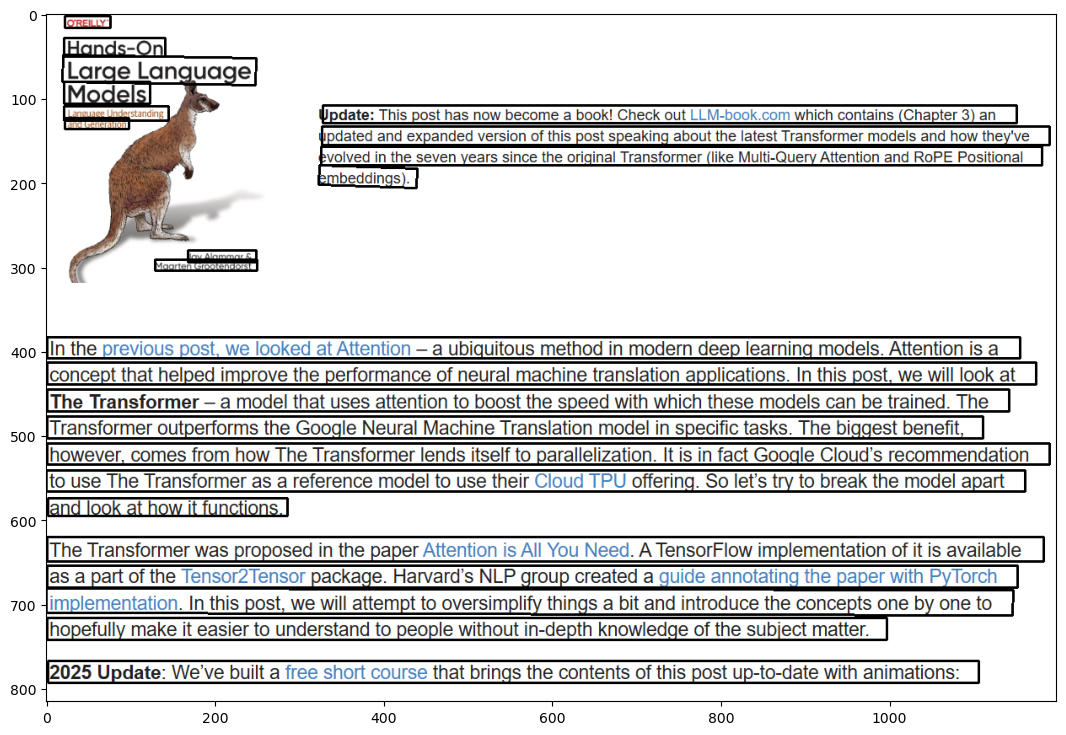

CPU times: total: 21.7 s
Wall time: 5.91 s


In [62]:
%%time
text = run_ocr_on_image(
    [det_session, rec_session], charset, det_size, rec_h, image_path=img_path
)

In [63]:
text

["O'REILLY",
 'Hands-On',
 'Large Language',
 'Model',
 'Languege Understanding',
 'Update: This post has now become a book! Check out LLM-book.com which contains (Chapter 3) an.',
 'and Geer',
 "updated and expanded version of this post speaking about the latest Transformer models and how they've",
 'evolved in the seven years since te original Transtormer like Multi-Query Attention and RoPE Positional',
 'embeddings).',
 'Jay lammar',
 'Maarten rr',
 'In the previous post, we looked at Attention – a ubiquitous method in modern deep learning models. Atention is a',
 'concept that helped improve the performance of neural machine translation applications. In this post, we willook at',
 'The Transformer – a model that uses attention to boost the speed with which these models can be trained. The',
 'Transformer outperforms the Google Neural Machine Translation model in specific tasks. The biggest benefit,',
 "however, comes from how The Transformer lends itself to parallization. It is in 